# RST Parse-Tree Viewer
Use this notebook to render RS3 files into PNG and preview the parse tree inline.

In [1]:
from pathlib import Path
from IPython.display import Image, display
import isanlp_rst
import isanlp_rst.rstviewer.main as m

# Patch viewer JS to avoid "Illegal return statement" during to_png.
m.JS_GET_DOCUMENT_WIDTH = '(() => {' + m.JS_GET_DOCUMENT_WIDTH + '})()'
m.JS_GET_DOCUMENT_HEIGHT = '(() => {' + m.JS_GET_DOCUMENT_HEIGHT + '})()'

# Robust root detection for both interactive notebook runs and programmatic execution.
cwd = Path.cwd().resolve()
root = cwd if (cwd / 'data' / 'artifacts').exists() else cwd.parent

# rs3_dir = root / 'data' / 'artifacts' / 'rst_rs3'
# png_dir = root / 'data' / 'artifacts' / 'rst_images'

# Ensure output directories exist for inference results and visualizations.
rs3_dir = root / 'data' / 'inference' / 'rst_rs3'
png_dir = root / 'data' / 'inference' / 'rst_images'

png_dir.mkdir(parents=True, exist_ok=True)

rs3_files = sorted(rs3_dir.glob('*.rs3'))
print(f'Project root: {root}')
print(f'RS3 files found: {len(rs3_files)}')
for i, f in enumerate(rs3_files, 1):
    print(f'{i:2d}. {f.name}')

c:\Users\Madduru Sai Chandra\anaconda3\envs\squad-rst-v2-py312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: C:\Users\Madduru Sai Chandra\Desktop\Sqaud_RST_V2
RS3 files found: 6
 1. squad_v2_56d61c4e1c85041400946f1d.rs3
 2. squad_v2_56dff532231d4119001abf05.rs3
 3. squad_v2_570602f875f01819005e786f.rs3
 4. squad_v2_5727ebe03acd2414000deff0.rs3
 5. squad_v2_572a60d8d562191400bc86a5.rs3
 6. squad_v2_572abec0be1ee31400cb8201.rs3


In [2]:
# Generate PNGs for all RS3 files (default behavior).
import subprocess
import sys

if not rs3_files:
    raise ValueError('No RS3 files found in data/artifacts/rst_rs3')

# Keep a selected file for inline display in Cell 4.
file_index = 0  # change this to preview a different generated image
selected_rs3 = rs3_files[file_index]
output_png = png_dir / (selected_rs3.stem + '.png')

print(f'Total RS3 files: {len(rs3_files)}')

success = 0
failed = []
for src in rs3_files:
    dst = png_dir / f'{src.stem}.png'
    code = (
        "import isanlp_rst; "
        "import isanlp_rst.rstviewer.main as m; "
        "m.JS_GET_DOCUMENT_WIDTH='(() => {'+m.JS_GET_DOCUMENT_WIDTH+'})()'; "
        "m.JS_GET_DOCUMENT_HEIGHT='(() => {'+m.JS_GET_DOCUMENT_HEIGHT+'})()'; "
        f"isanlp_rst.to_png(r'{src}', r'{dst}')"
    )
    try:
        subprocess.run([sys.executable, "-c", code], check=True)
        success += 1
    except subprocess.CalledProcessError as e:
        failed.append((src.name, str(e)))

print(f'Generated PNGs: {success}/{len(rs3_files)}')
if failed:
    print('Failed files:')
    for name, err in failed:
        print(f' - {name}: {err}')

print('Selected RS3 for display:', selected_rs3)
print('Selected PNG path      :', output_png)
print('Selected PNG exists    :', output_png.exists())

Total RS3 files: 6
Generated PNGs: 6/6
Selected RS3 for display: C:\Users\Madduru Sai Chandra\Desktop\Sqaud_RST_V2\data\inference\rst_rs3\squad_v2_56d61c4e1c85041400946f1d.rs3
Selected PNG path      : C:\Users\Madduru Sai Chandra\Desktop\Sqaud_RST_V2\data\inference\rst_images\squad_v2_56d61c4e1c85041400946f1d.png
Selected PNG exists    : True


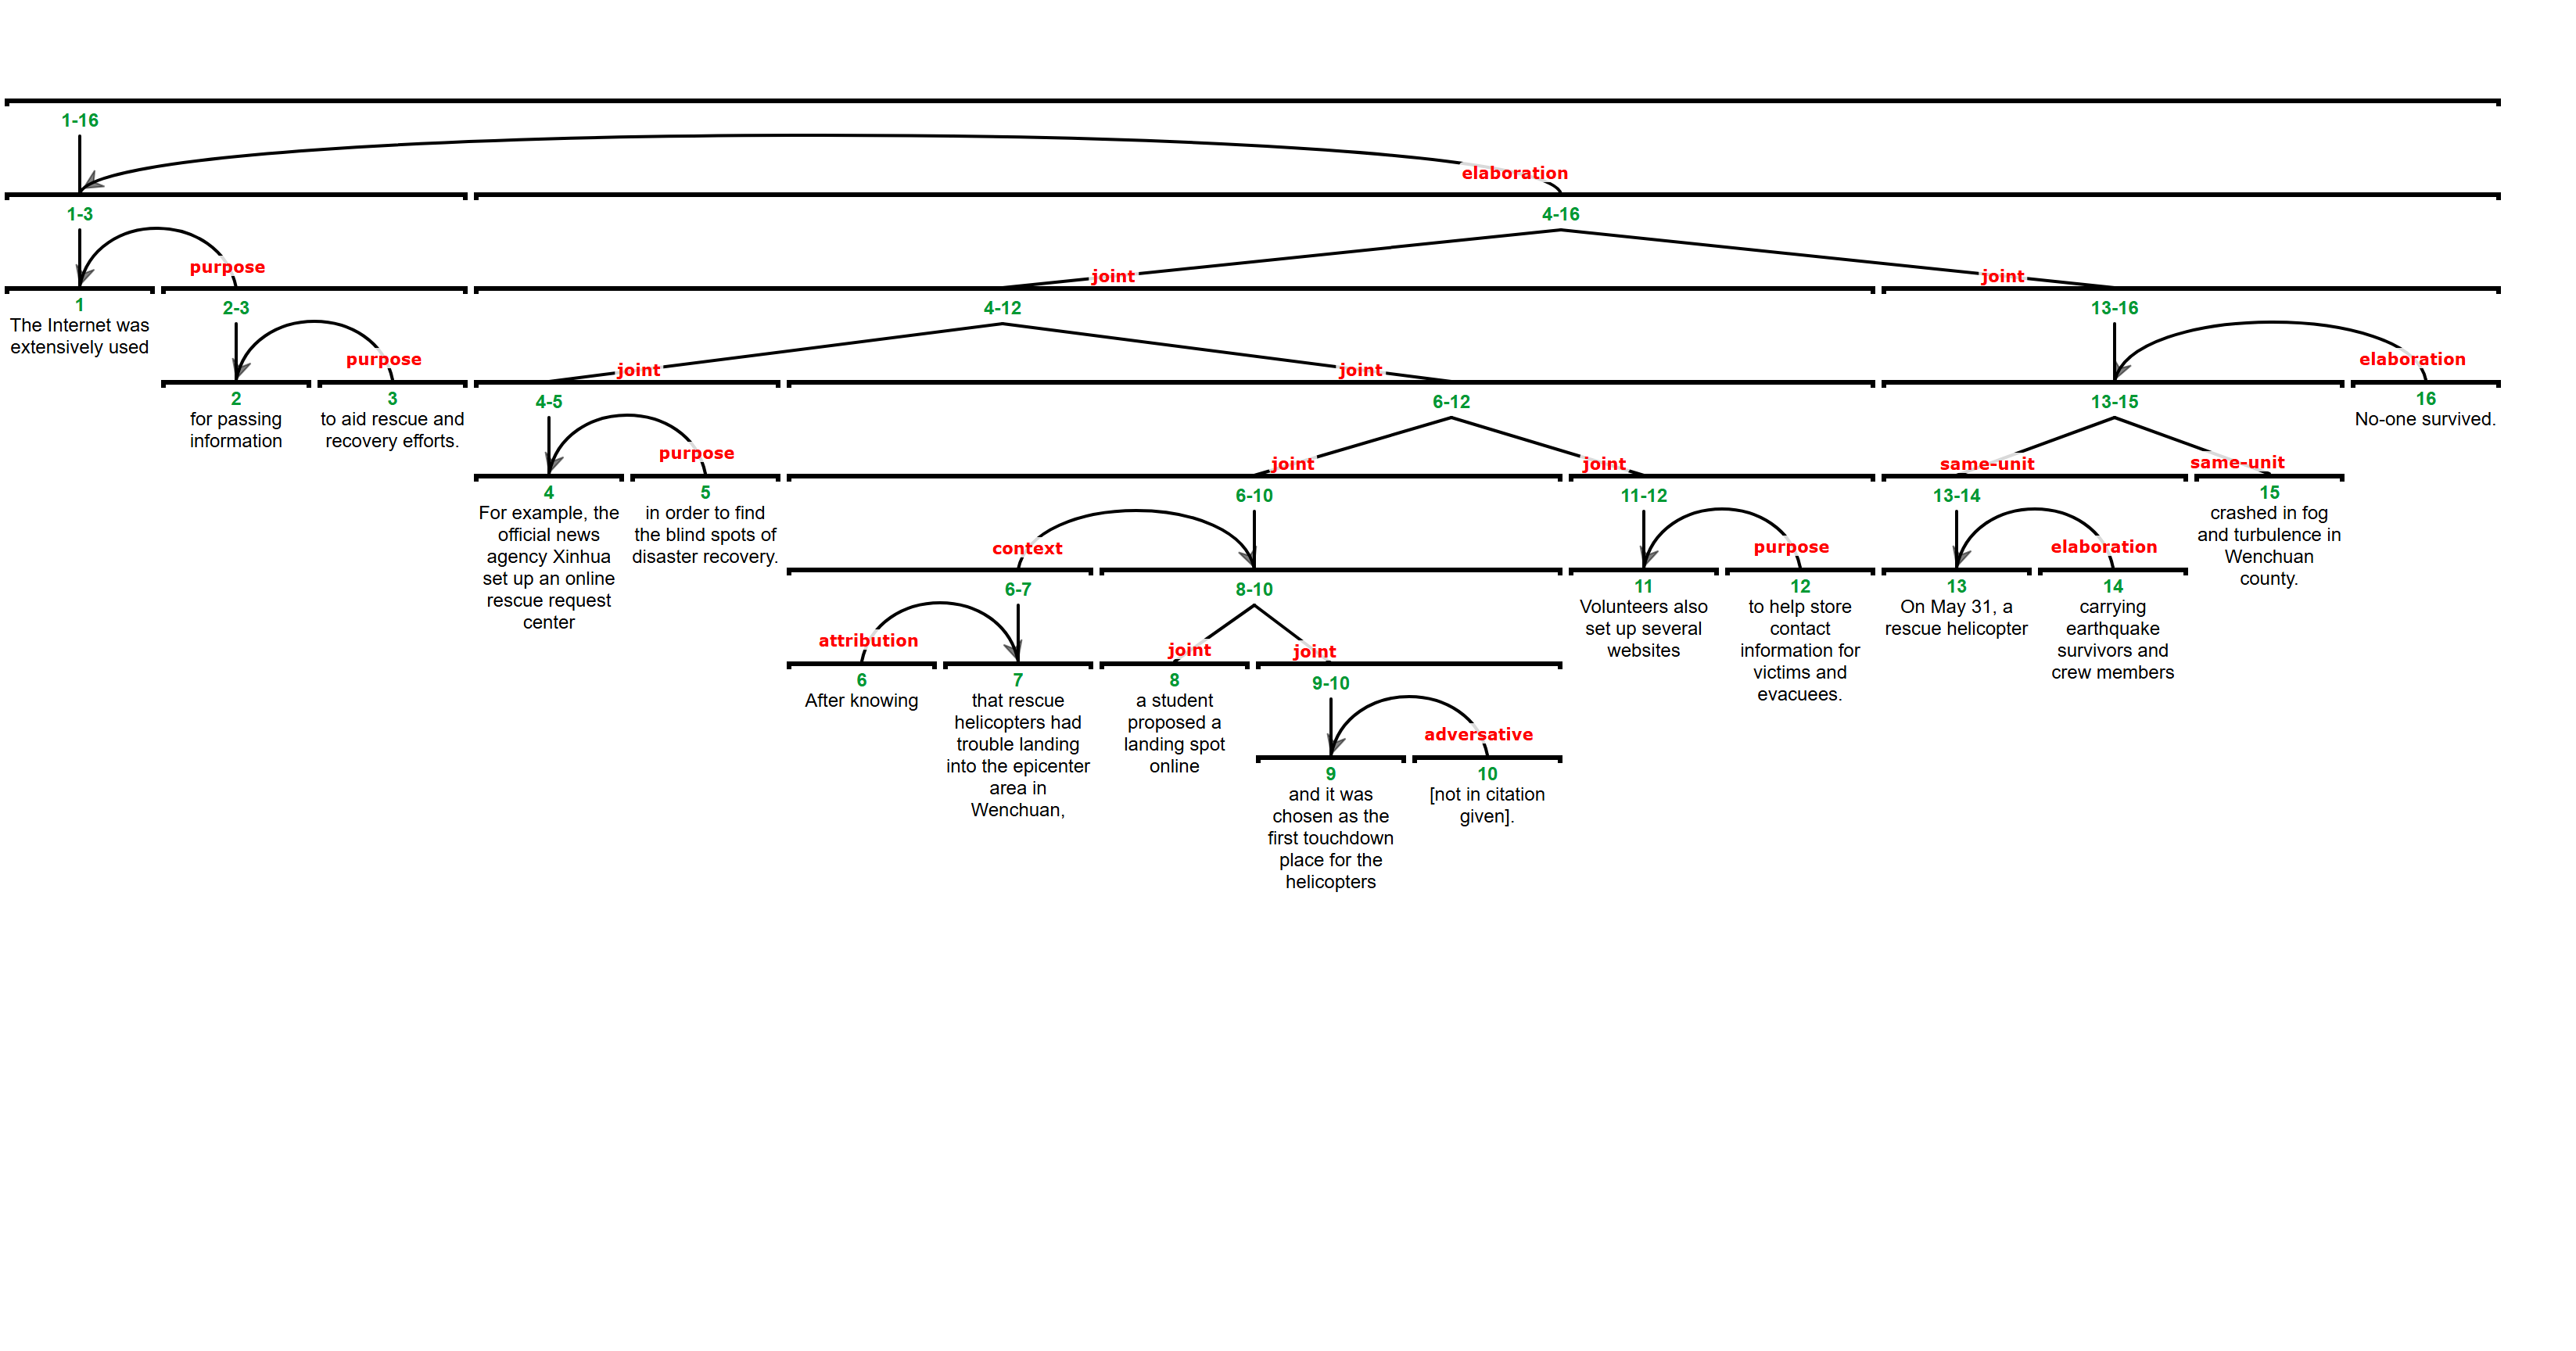

In [10]:
# Display parse-tree image inline
display(Image(filename=str(output_png)))